In [45]:
from utilities import init_bigquery_client
from google.cloud import bigquery
import os
import pandas as pd
import numpy as np
import plotly.express as px

from plotnine import *

#init BigQuery client
bq = init_bigquery_client()

Using BigQuery credentials: etl-testing-478716-c0b6c2c512e0.json


## Bulk Queries

In [46]:
# Read from the 'events' table in BigQuery
query = """
    SELECT *
    FROM `etl-testing-478716.firebase_etl_prod.events`
"""
events_df = bq.query(query).to_dataframe()

# Read from the 'userinvites' table in BigQuery
query = """
    SELECT *
    FROM `etl-testing-478716.firebase_etl_prod.userinvites`
"""
userinvites_df = bq.query(query).to_dataframe()

# Read from the 'users' table in BigQuery
query = """
    SELECT *
    FROM `etl-testing-478716.firebase_etl_prod.users`
"""
users_df = bq.query(query).to_dataframe()

/opt/miniconda3/envs/heyyall/lib/python3.13/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.


In [73]:
#Creating previous joiners df for network analysis
userinvites_df.rename(columns={'user_id': 'invite_user_id',
                               'createdAt': 'invite_created_at'}, inplace=True)

events_df.rename(columns={'user_id': 'event_user_id',
                          'createdAt': 'event_created_at'}, inplace=True)

# Merge the 'events' and 'userinvites' DataFrames on the 'event_id' column
merged_df = pd.merge(events_df, userinvites_df, left_on = 'document_id', 
                     right_on='event_id', how='inner', suffixes=('_events', '_userinvites'))
keep_columns = ['event_id', 'title', 'invite_user_id','event_user_id','type','status', 'invite_created_at', 'event_created_at']

filtered_df = merged_df[keep_columns]
filtered_df = filtered_df[filtered_df['status'] == 'accepted']
filtered_df = filtered_df.drop_duplicates(subset=['event_id', 'invite_user_id', 'event_user_id','type','status'])

#getting count of how many times each user attended events planned by each event planner
previous_joiners_df = filtered_df.groupby(['invite_user_id', 'event_user_id']).size().reset_index(name='pair_count')

#merging on if event planner is a businses user
biz_user_df = users_df[['user_id', 'businessUser']]

previous_joiners_df = previous_joiners_df.merge(biz_user_df, left_on='event_user_id', right_on='user_id', how='left')
previous_joiners_df['businessUser'] = previous_joiners_df['businessUser'].fillna(False)
previous_joiners_df = previous_joiners_df.rename(columns={'businessUser':'event_businessUser'})

In [74]:
#getting span of time user has been attending events planned by each event planner
first_attend_df = filtered_df.groupby(['invite_user_id', 'event_user_id'])['invite_created_at'].min().reset_index(name='first_attend_date')
last_attend_df = filtered_df.groupby(['invite_user_id', 'event_user_id'])['invite_created_at'].max().reset_index(name='last_attend_date')

previous_joiners_df = previous_joiners_df.merge(first_attend_df, on=['invite_user_id', 'event_user_id'], how='left')
previous_joiners_df = previous_joiners_df.merge(last_attend_df, on=['invite_user_id', 'event_user_id'], how='left')

previous_joiners_df['attend_span'] = (previous_joiners_df['last_attend_date'] - previous_joiners_df['first_attend_date']).dt.total_seconds() / 3600

### Generating Network Graph

In [50]:
import networkx as nx
import matplotlib.pyplot as plt
import scipy as sp

In [78]:
#segmenting previous joiner networks by general event planners and business event planners
G_general_user = nx.from_pandas_edgelist(previous_joiners_df[previous_joiners_df['event_businessUser'] == False], 'invite_user_id', 'event_user_id')
G_business_user = nx.from_pandas_edgelist(previous_joiners_df[previous_joiners_df['event_businessUser'] == True], 'invite_user_id', 'event_user_id')

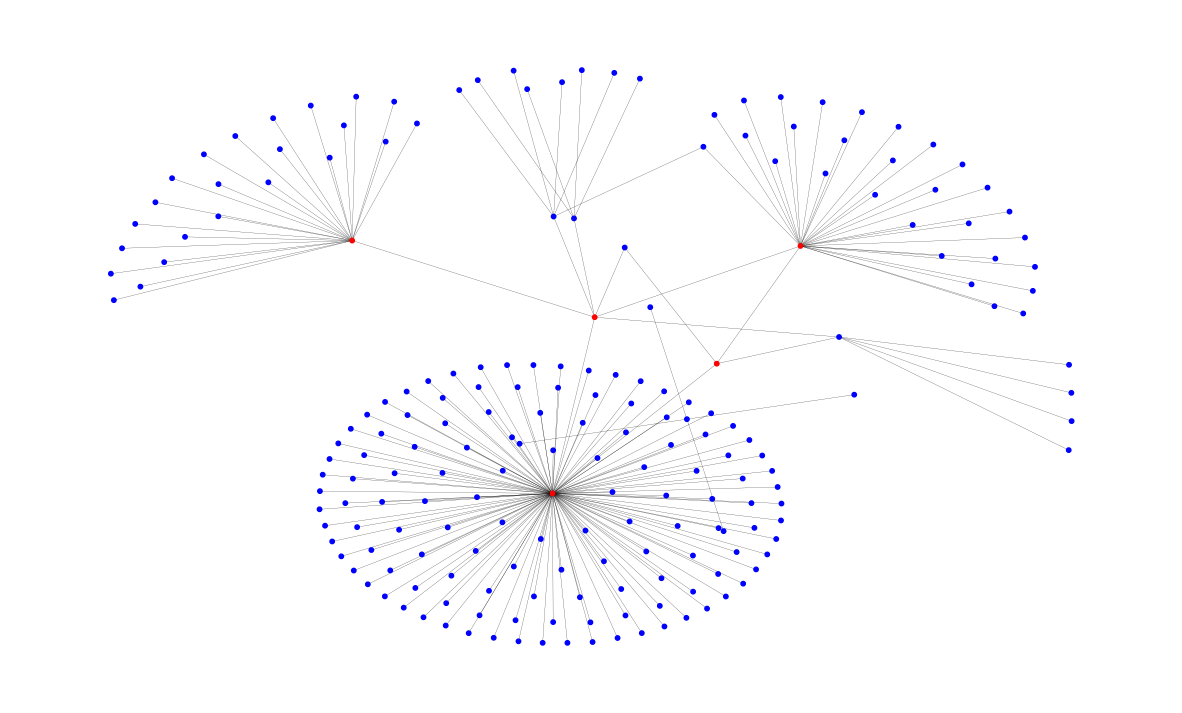

In [87]:
#Creating graphic of business user previous joiner network
betweeness_centrality = nx.centrality.betweenness_centrality(G_business_user)

# Find top 5 nodes by betweenness centrality
top5_nodes = sorted(betweeness_centrality, key=betweeness_centrality.get, reverse=True)[:5]

# Assign colors: red for top 5, blue for others
node_colors = ["red" if node in top5_nodes else "blue" for node in G_business_user.nodes()]

pos = nx.kamada_kawai_layout(G_business_user)
fig, ax = plt.subplots(figsize=(15, 9))
ax.axis("off")
plot_options = {"node_size": 10, "with_labels": False, "width": 0.15}
nx.draw_networkx(G_business_user, pos=pos, ax=ax, node_color=node_colors, **plot_options)

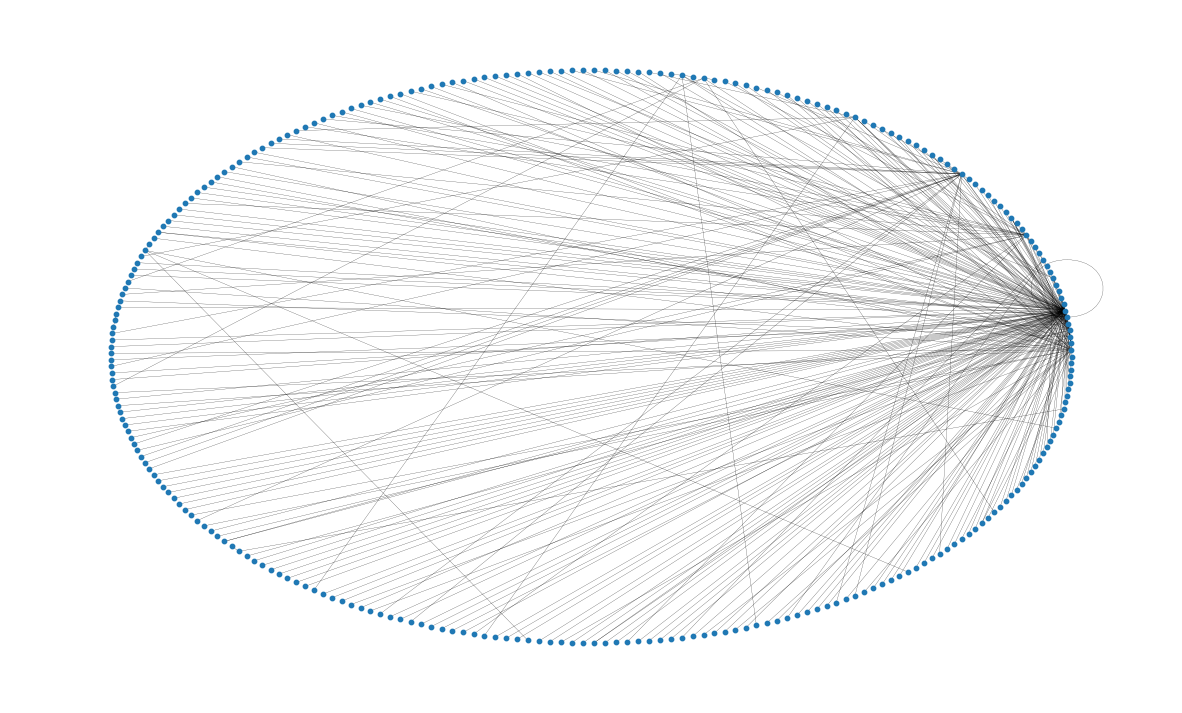

In [55]:
pos = nx.circular_layout(G)
fig, ax = plt.subplots(figsize=(15, 9))
ax.axis("off")
plot_options = {"node_size": 10, "with_labels": False, "width": 0.15}
nx.draw_networkx(G, pos=pos, ax=ax, **plot_options)

### Degree centrality

Identifying which event planners have the highest degree and which attendees go to the most distinct events by planner

In [96]:
#Degree centrality of event planners 
event_planner_centrality = nx.degree_centrality(G_business_user)

## Bipartite Network Analysis

A bipartite network is one where you can separate nodes into distinct sets. There can be edges between the sets but not within sets. 
For our work using a bipartite network with business users and event attendees as our distinct sets allows for easier interpretation.

In [112]:
# Add nodes with bipartite attribute
# 0 = attendees, 1 = planners
#filtering to business user event planners
df = previous_joiners_df[previous_joiners_df['event_businessUser']==True]
G = nx.Graph()

#creating attendee and planner lists
attendees = df['invite_user_id'].unique()
planners = df['event_user_id'].unique()

G.add_nodes_from(attendees, bipartite=0, node_type='attendee')
G.add_nodes_from(planners, bipartite=1, node_type='planner')

# Add weighted edges
edges = [(row['invite_user_id'], row['event_user_id'], row['pair_count']) 
         for _, row in df.iterrows()]
G.add_weighted_edges_from(edges)

print(f"Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
print(f"Attendees: {len(attendees)}, Planners: {len(planners)}")

Graph created with 205 nodes and 207 edges
Attendees: 197, Planners: 8


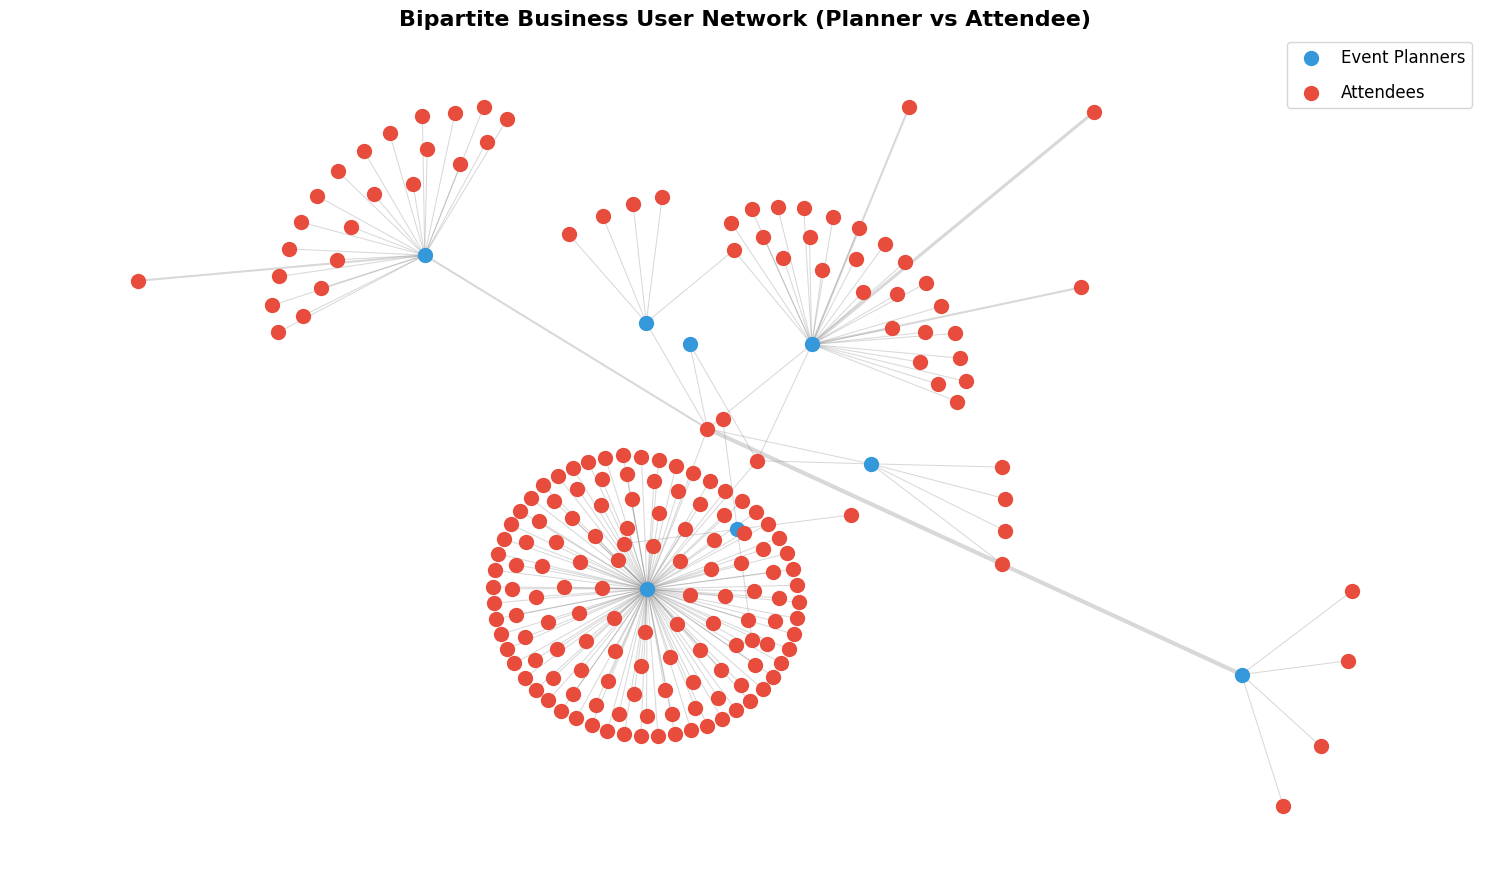

In [125]:
def visualize_bipartite_kamada_kawai(G, title="Event Planning Network"):
    """
    Visualize bipartite network with Kamada-Kawai layout
    """
    attendees = {n for n, d in G.nodes(data=True) if d['bipartite'] == 0}
    planners = {n for n, d in G.nodes(data=True) if d['bipartite'] == 1}
    
    # Kamada-Kawai layout
    pos = nx.kamada_kawai_layout(G, weight='weight')
    
    plt.figure(figsize=(15, 9))
    
    # Draw planners (blue, larger)
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=planners,
        node_color='#3498db',
        node_size=100,
        label='Event Planners'
    )
    
    # Draw attendees (orange, smaller)
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=attendees,
        node_color='#e74c3c',
        node_size=100,
        label='Attendees'
    )
    
    # Draw edges with varying width based on pair_count
    edges = G.edges(data=True)
    weights = [d['weight'] for u, v, d in edges]
    max_weight = max(weights)
    
    nx.draw_networkx_edges(
        G, pos,
        width=[w/max_weight * 3 for w in weights],
        alpha=0.3,
        edge_color='gray'
    )
    
    plt.title(title, fontsize=16, fontweight='bold')
    plt.legend(scatterpoints=1, frameon=True, labelspacing=1, fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    # plt.savefig('bipartite_network_kamada_kawai.png', dpi=300, bbox_inches='tight')
    plt.show()


visualize_bipartite_kamada_kawai(G, title="Bipartite Business User Network (Planner vs Attendee)")


Projection turns the bipartite graph into a unipartite graph where event planners are connected and overlapping attendees are returned as the edge weight.

Business Insights:

* Competitor Analysis: Planners with many shared attendees have overlapping audiences
* Collaboration Opportunities: Planners with moderate overlap might benefit from co-hosting
* Market Segmentation: Planners with no connections serve completely different niches
* Cross-promotion: Planners with high overlap could recommend each other's events


In [123]:
#projected networks 
def create_projected_networks(G):
    """
    Create planner-to-planner and attendee-to-attendee projections
    """
    attendees = {n for n, d in G.nodes(data=True) if d['bipartite'] == 0}
    planners = {n for n, d in G.nodes(data=True) if d['bipartite'] == 1}
    
    # Planner projection (planners connected by shared attendees)
    planner_projection = nx.bipartite.weighted_projected_graph(G, planners)
    
    # Attendee projection (attendees connected by shared planners)
    attendee_projection = nx.bipartite.weighted_projected_graph(G, attendees)
    
    return planner_projection, attendee_projection

planner_proj, attendee_proj = create_projected_networks(G)

In [124]:
#extractnig planner to planner pairings with count of attendee overlap
def get_projection_edges_df(projection_graph, node1_col='planner_1', node2_col='planner_2'):
    """
    Convert projection graph to a DataFrame of all edges with weights
    """
    edges_data = []
    
    for u, v, data in projection_graph.edges(data=True):
        edges_data.append({
            node1_col: u,
            node2_col: v,
            'weight': data.get('weight', 1),  # Number of shared attendees
            'planner_1_degree': projection_graph.degree(u, weight='weight'),
            'planner_2_degree': projection_graph.degree(v, weight='weight')
        })
    
    df_edges = pd.DataFrame(edges_data)
    
    # Add normalized metrics
    if len(df_edges) > 0:
        # Jaccard-style normalization (shared / total unique attendees)
        # This requires going back to original bipartite graph
        df_edges['avg_degree'] = (df_edges['planner_1_degree'] + df_edges['planner_2_degree']) / 2
        df_edges['overlap_ratio'] = df_edges['weight'] / df_edges['avg_degree']
    
    return df_edges.sort_values('weight', ascending=False)

# Get all planner-to-planner connections
planner_edges_df = get_projection_edges_df(planner_proj, 'planner_1', 'planner_2')

print(f"Total planner-planner connections: {len(planner_edges_df)}")
print("\nTop 10 planner pairs by shared attendees:")
print(planner_edges_df.head(10))

Total planner-planner connections: 21

Top 10 planner pairs by shared attendees:
                       planner_1                     planner_2  weight  \
10  k6BkWiiMfjfN86cdJu1pXsKIs6A2  xqtYGaFNqxTJURg1vK1sZwU37zi2       2   
7   k6BkWiiMfjfN86cdJu1pXsKIs6A2  Z347q5fi8fUr1eeY2mt2W8rrmN92       2   
17  Z347q5fi8fUr1eeY2mt2W8rrmN92  xqtYGaFNqxTJURg1vK1sZwU37zi2       2   
16  Z347q5fi8fUr1eeY2mt2W8rrmN92  rX424wIcbSWxdPNjYrzyGQFGZ8y2       2   
9   k6BkWiiMfjfN86cdJu1pXsKIs6A2  rX424wIcbSWxdPNjYrzyGQFGZ8y2       2   
20  rX424wIcbSWxdPNjYrzyGQFGZ8y2  xqtYGaFNqxTJURg1vK1sZwU37zi2       2   
5   PlJR3clMj8QQwTXwsfGGclxGNFE3  xqtYGaFNqxTJURg1vK1sZwU37zi2       2   
6   k6BkWiiMfjfN86cdJu1pXsKIs6A2  8SGMqkCelsT88n2qU61lWhFWIrA3       1   
8   k6BkWiiMfjfN86cdJu1pXsKIs6A2  0MFEFCTVAmScoWdnIrrP6duF6pU2       1   
4   PlJR3clMj8QQwTXwsfGGclxGNFE3  rX424wIcbSWxdPNjYrzyGQFGZ8y2       1   

    planner_1_degree  planner_2_degree  avg_degree  overlap_ratio  
10                 9                

In [101]:
def calculate_degree_centrality(G, df):
    """
    Calculate both weighted and unweighted degree centrality
    """
    # Separate nodes by type
    attendees = {n for n, d in G.nodes(data=True) if d['bipartite'] == 0}
    planners = {n for n, d in G.nodes(data=True) if d['bipartite'] == 1}
    
    # Unweighted degree centrality
    degree_cent = nx.degree_centrality(G)
    
    # Weighted degree centrality (strength)
    weighted_degree = dict(G.degree(weight='weight'))
    
    # Create DataFrames for analysis
    # Planner metrics
    planner_metrics = pd.DataFrame([
        {
            'planner_id': p,
            'unique_attendees': G.degree(p),  # Unweighted
            'total_attendance': weighted_degree[p],  # Weighted
            'avg_repeat_rate': weighted_degree[p] / G.degree(p) if G.degree(p) > 0 else 0,
            'degree_centrality': degree_cent[p]
        }
        for p in planners
    ]).sort_values('unique_attendees', ascending=False)
    
    # Attendee metrics
    attendee_metrics = pd.DataFrame([
        {
            'attendee_id': a,
            'planners_attended': G.degree(a),  # Unweighted
            'total_events': weighted_degree[a],  # Weighted
            'avg_loyalty': weighted_degree[a] / G.degree(a) if G.degree(a) > 0 else 0,
            'degree_centrality': degree_cent[a]
        }
        for a in attendees
    ]).sort_values('planners_attended', ascending=False)
    
    return planner_metrics, attendee_metrics

planner_metrics, attendee_metrics = calculate_degree_centrality(G, df)

# Display top planners and attendees
print("\n=== TOP 10 PLANNERS BY REACH ===")
print(planner_metrics.head(5))

print("\n=== TOP 10 ATTENDEES BY DIVERSITY ===")
print(attendee_metrics.head(10))


=== TOP 10 PLANNERS BY REACH ===
                      planner_id  unique_attendees  total_attendance  \
4   Z347q5fi8fUr1eeY2mt2W8rrmN92               129               129   
15  xqtYGaFNqxTJURg1vK1sZwU37zi2                31                35   
6   QFxHzayNZSRyDcrLAPJf5Oi9dY42                26                37   
22  0MFEFCTVAmScoWdnIrrP6duF6pU2                24                26   
9   9gHK6nfBJrVyx1543vFgvOKL85N2                23                25   

    avg_repeat_rate  degree_centrality  
4          1.000000           0.474265  
15         1.129032           0.113971  
6          1.423077           0.095588  
22         1.083333           0.088235  
9          1.086957           0.084559  

=== TOP 10 ATTENDEES BY DIVERSITY ===
                      attendee_id  planners_attended  total_events  \
125  Sw43fIOUtCRfWAvS7zaGzKP5bqD2                  2             2   
223  tO81D4aQWpWiCq1KszFrlveKTqf2                  2             2   
150  lEPaZX3MRNNo4p7EQRnLNP0jPDl2     

In [108]:
def calculate_betweenness_centrality(G):
    """
    Find users who act as bridges in the network
    """
    # This can be slow for large graphs
    betweenness = nx.betweenness_centrality(G, weight='weight')
    
    # Separate by type
    attendees = {n for n, d in G.nodes(data=True) if d['bipartite'] == 0}
    planners = {n for n, d in G.nodes(data=True) if d['bipartite'] == 1}
    
    planner_betweenness = pd.DataFrame([
        {'planner_id': p, 'betweenness': betweenness[p]}
        for p in planners
    ]).sort_values('betweenness', ascending=False)
    
    attendee_betweenness = pd.DataFrame([
        {'attendee_id': a, 'betweenness': betweenness[a]}
        for a in attendees
    ]).sort_values('betweenness', ascending=False)
    
    return planner_betweenness, attendee_betweenness

# Warning: This can be slow for large networks
# Consider using approximate betweenness for large graphs
print("\nCalculating betweenness centrality (this may take a while)...")
planner_betweenness, attendee_betweenness = calculate_betweenness_centrality(G)

print("\n=== TOP 10 BRIDGE PLANNERS ===")
print(planner_betweenness.head(5))

print("\n=== TOP 10 BRIDGE ATTENDEES ===")
print(attendee_betweenness.head(5))


Calculating betweenness centrality (this may take a while)...

=== TOP 10 BRIDGE PLANNERS ===
                      planner_id  betweenness
4   Z347q5fi8fUr1eeY2mt2W8rrmN92     0.654948
6   QFxHzayNZSRyDcrLAPJf5Oi9dY42     0.365732
10  0PNBuWC4P5by27fmCRYtT89Jdtl1     0.189998
15  xqtYGaFNqxTJURg1vK1sZwU37zi2     0.184210
22  0MFEFCTVAmScoWdnIrrP6duF6pU2     0.145946

=== TOP 10 BRIDGE ATTENDEES ===
                      attendee_id  betweenness
223  tO81D4aQWpWiCq1KszFrlveKTqf2     0.000102
125  Sw43fIOUtCRfWAvS7zaGzKP5bqD2     0.000027
156  ptWmBVNoH9XUBjg2Hjv4Zm0rMXJ3     0.000000
158  QdlsZ9Vf9yZhvdHp9QUzdzyzpGe2     0.000000
159  utvixsibzBe4FKYdCF8e46zEp4G3     0.000000
